In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

def std_layout(xlabel, ylabel):
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.xlabel(xlabel, fontsize=15)
    plt.ylabel(ylabel, fontsize=15)
    ax.spines[['right','top']].set_visible(False)
    plt.tight_layout()
    
F = 8.922473368689328
N_0 = 1539351

In [2]:
def a_n_function(alpha): # a_n-1 = epsilon
    n = 0
    S = 1
    alphas = [alpha]
    probs = []
    epsilons = [0]
    
    for i in range(100):
        p = 1./(1+alpha)
        probs.append(p) 
        q = 1-p
        s = 1+p
        S = S*s
        f = p*q/s
        n = n*s + f
        alpha = alpha*s; alphas.append(alpha)
        epsilons.append(n/S)
    
    return epsilons, alphas, probs

## S1: Improving the model means improving the constancy of the Fano factor

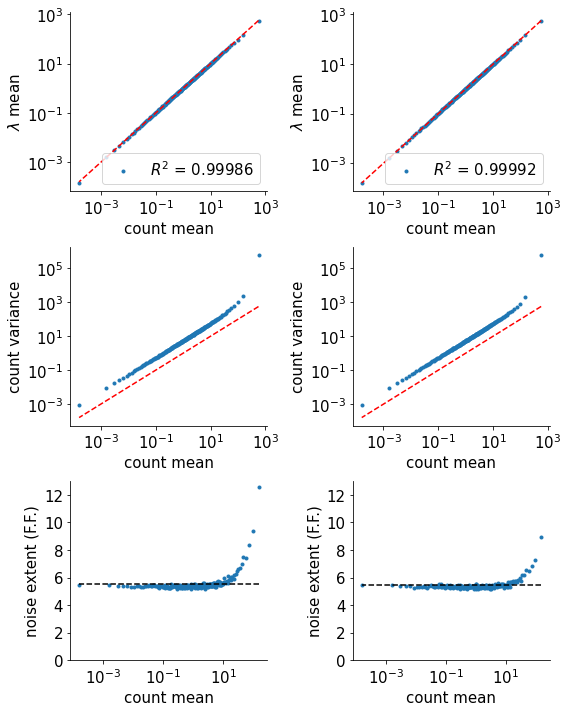

In [10]:
plt.figure(figsize=(8,10), facecolor='white')

df_bins_IM = pd.read_csv('../binning_real_data_q/df_bins_Dalkara_IM_200bins.csv',index_col=0)
df_bins_Potts = pd.read_csv('../binning_real_data_q/df_bins_Dalkara_Potts.csv',index_col=0)

ax = plt.subplot(3,2,1)
x = df_bins_IM['mean_count']
y = df_bins_IM['mean_lambda']
R2 = r2_score(np.log(x), np.log(y))
plt.scatter(x,y,marker='.', label=r'$R^2$ = %.5f'%R2)
plt.plot(x,x,linestyle='--', color='red')
plt.xscale('log')
plt.yscale('log')
std_layout('count mean', r'$\lambda$ mean')
plt.legend(fontsize=15)

ax = plt.subplot(3,2,2)
x = df_bins_Potts['mean_count']
y = df_bins_Potts['mean_lambda']
R2 = r2_score(np.log(x), np.log(y))
plt.scatter(x,y,marker='.', label=r'$R^2$ = %.5f'%R2)
plt.plot(x,x,linestyle='--', color='red')
plt.xscale('log')
plt.yscale('log')
std_layout('count mean', r'$\lambda$ mean')
plt.legend(fontsize=15)

ax = plt.subplot(3,2,3)
x = df_bins_IM['mean_count']
y = df_bins_IM['var_count']
plt.scatter(x,y,marker='.')
plt.plot(x,x,linestyle='--', color='red')
plt.xscale('log')
plt.yscale('log')
std_layout('count mean', 'count variance')

ax = plt.subplot(3,2,4)
x = df_bins_Potts['mean_count']
y = df_bins_Potts['var_count']
plt.scatter(x,y,marker='.')
plt.plot(x,x,linestyle='--', color='red')
plt.xscale('log')
plt.yscale('log')
std_layout('count mean', 'count variance')

ax = plt.subplot(3,2,5)
x = df_bins_IM['mean_count']
y = (df_bins_IM['var_count'] - df_bins_IM['var_lambda'])/x
x=x.loc[y>0]
y=y.loc[y>0]
plt.ylim(0,13)
plt.scatter(x,y,marker='.')
plt.hlines(y.mean(), x.iloc[0], x.iloc[-1], linestyle='--', color='black')
plt.xscale('log')
std_layout('count mean', 'noise extent (F.F.)')

ax = plt.subplot(3,2,6)
x = df_bins_Potts['mean_count']
y = (df_bins_Potts['var_count'] - df_bins_Potts['var_lambda'])/x
x=x.loc[y>0]
y=y.loc[y>0]
plt.ylim(0,13)
plt.scatter(x,y,marker='.')
plt.hlines(y.mean(), x.iloc[0], x.iloc[-1], linestyle='--', color='black')
plt.xscale('log')
std_layout('count mean', 'noise extent (F.F.)')

plt.savefig('Dalkara_supp1.png',dpi=1200)

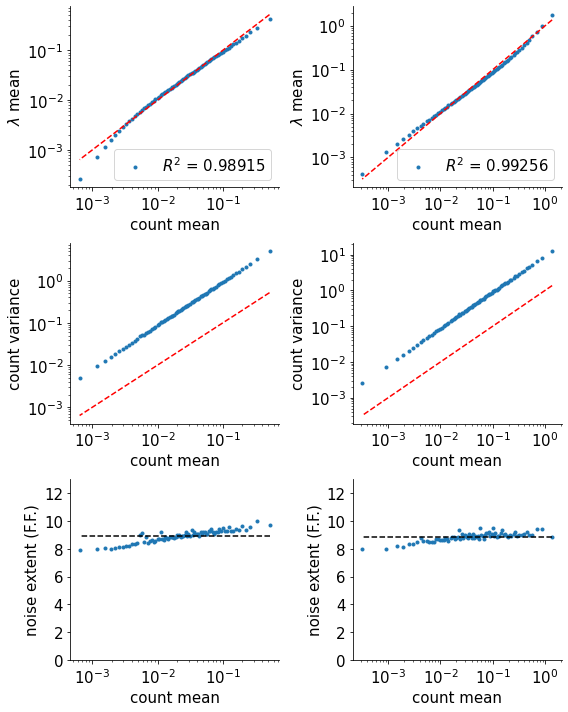

In [11]:
plt.figure(figsize=(8,10), facecolor='white')

df_bins_IM = pd.read_csv('../binning_real_data_q/df_bins_Byrne_IM_80bins.csv',index_col=0)
df_bins_Potts = pd.read_csv('../binning_real_data_q/df_bins_Byrne_Potts.csv',index_col=0)

ax = plt.subplot(3,2,1)
x = df_bins_IM['mean_count']
y = df_bins_IM['mean_lambda']
R2 = r2_score(np.log(x), np.log(y))
plt.scatter(x,y,marker='.', label=r'$R^2$ = %.5f'%R2)
plt.plot(x,x,linestyle='--', color='red')
plt.xscale('log')
plt.yscale('log')
std_layout('count mean', r'$\lambda$ mean')
plt.legend(fontsize=15)

ax = plt.subplot(3,2,2)
x = df_bins_Potts['mean_count']
y = df_bins_Potts['mean_lambda']
R2 = r2_score(np.log(x), np.log(y))
plt.scatter(x,y,marker='.', label=r'$R^2$ = %.5f'%R2)
plt.plot(x,x,linestyle='--', color='red')
plt.xscale('log')
plt.yscale('log')
std_layout('count mean', r'$\lambda$ mean')
plt.legend(fontsize=15, loc=4)

ax = plt.subplot(3,2,3)
x = df_bins_IM['mean_count']
y = df_bins_IM['var_count']
plt.scatter(x,y,marker='.')
plt.plot(x,x,linestyle='--', color='red')
plt.xscale('log')
plt.yscale('log')
std_layout('count mean', 'count variance')

ax = plt.subplot(3,2,4)
x = df_bins_Potts['mean_count']
y = df_bins_Potts['var_count']
plt.scatter(x,y,marker='.')
plt.plot(x,x,linestyle='--', color='red')
plt.xscale('log')
plt.yscale('log')
std_layout('count mean', 'count variance')

ax = plt.subplot(3,2,5)
x = df_bins_IM['mean_count']
y = (df_bins_IM['var_count'] - df_bins_IM['var_lambda'])/x
x=x.loc[y>0]
y=y.loc[y>0]
plt.ylim(0,13)
plt.scatter(x,y,marker='.')
plt.hlines(y.mean(), x.iloc[0], x.iloc[-1], linestyle='--', color='black')
plt.xscale('log')
std_layout('count mean', 'noise extent (F.F.)')

ax = plt.subplot(3,2,6)
x = df_bins_Potts['mean_count']
y = (df_bins_Potts['var_count'] - df_bins_Potts['var_lambda'])/x
x=x.loc[y>0]
y=y.loc[y>0]
plt.ylim(0,13)
plt.scatter(x,y,marker='.')
plt.hlines(y.mean(), x.iloc[0], x.iloc[-1], linestyle='--', color='black')
plt.xscale('log')
std_layout('count mean', 'noise extent (F.F.)')

plt.savefig('Byrne_supp1.png',dpi=1200)

## S2: mathematical framework with constant duplication probability confirms the proportionality of mean and variance

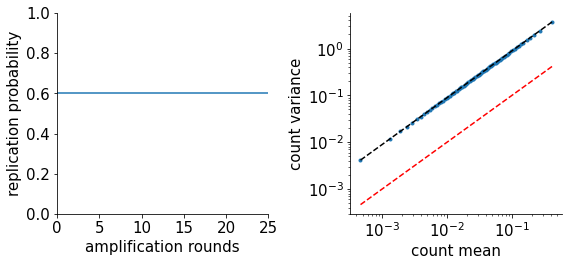

In [12]:
plt.figure(figsize=(8,3.8), facecolor='white')

df_bins = pd.read_csv('../simulations_p_constant/df_bins_simulation_Byrne_25amp_rounds.csv',index_col=0)

ax=plt.subplot(1,2,1)
plt.hlines(0.6,0,25)
plt.xlim(0,25)
plt.ylim(0,1)
std_layout('amplification rounds','replication probability')

ax=plt.subplot(1,2,2)
x = df_bins['mean_count']
y = df_bins['var_count']
plt.scatter(x,y,marker='.')
plt.xscale('log')
plt.yscale('log')
plt.plot(x,x,linestyle='--', color='red')
plt.plot(x, F*x, linestyle='--', color='black')
std_layout('count mean','count variance')
plt.savefig('supp2.png',dpi=1200)

## S3: a_n is approximately 1 for reasonable values of the ratio initial DNA - polymerase

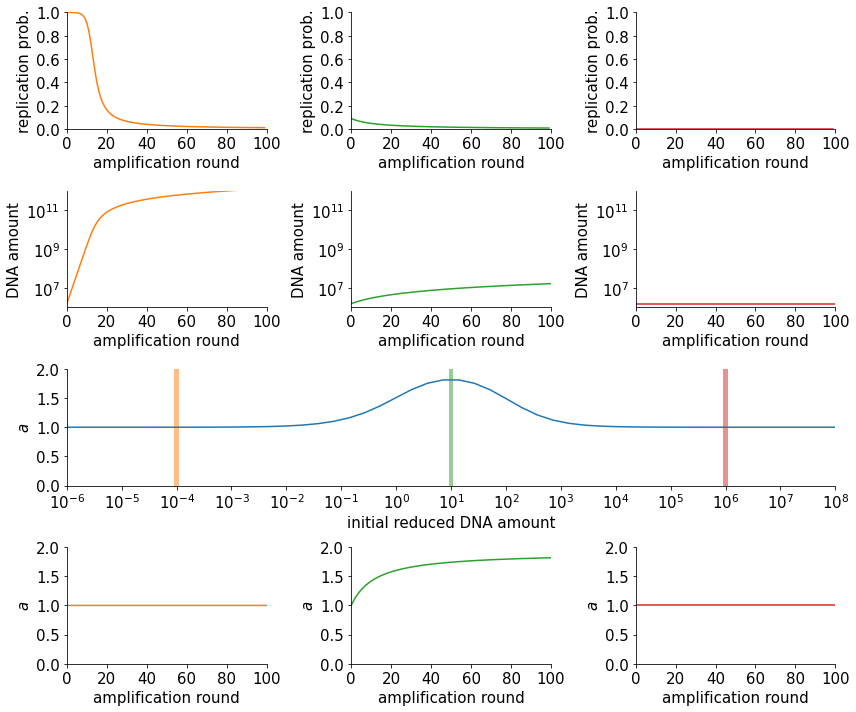

In [3]:
plt.figure(figsize=(12,10), facecolor='white')

N = 50

ax = plt.subplot(4,3,1)
_, _, p = a_n_function(1e-4)
plt.plot(p, color='C1')
plt.ylim(0,1)
plt.xlim(0,100)
std_layout('amplification round','replication prob.')

ax = plt.subplot(4,3,2)
_, _, p = a_n_function(1e1)
plt.plot(p, color='C2')
plt.ylim(0,1)
plt.xlim(0,100)
std_layout('amplification round','replication prob.')

ax = plt.subplot(4,3,3)
_, _, p = a_n_function(1e6)
plt.plot(p, color='C3')
plt.ylim(0,1)
plt.xlim(0,100)
std_layout('amplification round','replication prob.')

ax = plt.subplot(4,3,4)
alpha0 = 1e-4
_, alpha, _ = a_n_function(alpha0)
plt.plot(np.array(alpha)/alpha0*N_0, color='C1')
plt.xlim(0,100)
plt.ylim(1e6,1e12)
plt.yscale('log')
std_layout('amplification round','DNA amount')

ax = plt.subplot(4,3,5)
alpha0 = 1e1
_, alpha, _ = a_n_function(alpha0)
plt.plot(np.array(alpha)/alpha0*N_0, color='C2')
plt.xlim(0,100)
plt.ylim(1e6,1e12)
plt.yscale('log')
std_layout('amplification round','DNA amount')

ax = plt.subplot(4,3,6)
alpha0 = 1e6
_, alpha, _ = a_n_function(alpha0)
plt.plot(np.array(alpha)/alpha0*N_0, color='C3')
plt.xlim(0,100)
plt.ylim(1e6,1e12)
plt.yscale('log')
std_layout('amplification round','DNA amount')

ax=plt.subplot(4,1,3)

x = np.logspace(-6,8,N)
y = np.zeros(N)
for i in range(N):
    a_n, _, _ = a_n_function(x[i])
    y[i] = a_n[-1] + 1

plt.plot(x,y)
plt.xscale('log')
plt.ylim(0,2)
plt.xlim(1e-6,1e8)
std_layout('initial reduced DNA amount',r'$a$')
plt.yticks([0,0.5,1,1.5,2])
plt.xticks(np.logspace(-6,8,15))

plt.bar([1e-4],[2],color='C1', width=1e-4/5, alpha=0.5)
plt.bar([1e1],[2],color='C2', width=1e1/5, alpha=0.5)
plt.bar([1e6],[2],color='C3', width=1e6/5, alpha=0.5)


ax = plt.subplot(4,3,10)
a_n, _, _ = a_n_function(1e-4)
plt.plot(np.array(a_n)+1, color='C1')
plt.ylim(0,2)
plt.xlim(0,100)
std_layout('amplification round',r'$a$')
plt.yticks([0,0.5,1,1.5,2])

ax = plt.subplot(4,3,11)
a_n, _, _ = a_n_function(1e1)
plt.plot(np.array(a_n)+1, color='C2')
plt.ylim(0,2)
plt.xlim(0,100)
std_layout('amplification round',r'$a$')
plt.yticks([0,0.5,1,1.5,2])

ax = plt.subplot(4,3,12)
a_n, _, _ = a_n_function(1e6)
plt.plot(np.array(a_n)+1, color='C3')
plt.ylim(0,2)
plt.xlim(0,100)
std_layout('amplification round',r'$a$')
plt.yticks([0,0.5,1,1.5,2])

plt.tight_layout()
plt.savefig('supp3.png',dpi=1200)

## S4: the frequencies of the datasets

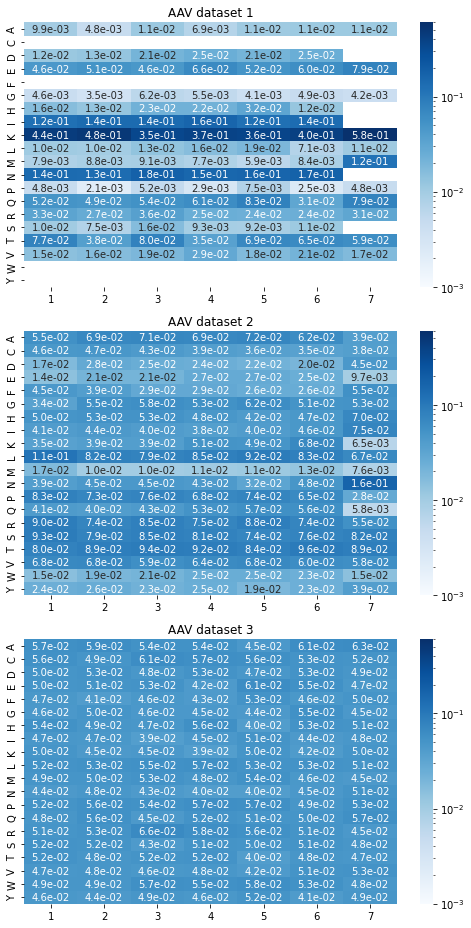

In [82]:
from matplotlib.colors import LogNorm

plt.figure(figsize=(7,13))

plt.subplot(3,1,1)
freq = np.loadtxt('frequencies/fields_DalkaraT0.csv',delimiter=',').T
freq = np.exp(freq)
freq[freq < 1e-7] = 0.
sns.heatmap(freq, mask=(freq<1e-7), annot=freq, fmt = '.1e',cmap='Blues', norm=LogNorm(vmin=1e-3, vmax=0.6))
plt.yticks(np.arange(20)+0.5,'ACDEFGHIKLMNPQRSTVWY')
plt.xticks(np.arange(7)+0.5, np.arange(1,8))
plt.title('AAV dataset 1')


plt.subplot(3,1,2)
freq = np.loadtxt('frequencies/fields_ByrneT0.csv',delimiter=',').T
freq = np.exp(freq)
freq[freq < 1e-7] = 0.
sns.heatmap(freq, annot=freq, fmt = '.1e',cmap='Blues', norm=LogNorm(vmin=1e-3, vmax=0.6))
plt.yticks(np.arange(20)+0.5,'ACDEFGHIKLMNPQRSTVWY')
plt.xticks(np.arange(7)+0.5, np.arange(1,8))
plt.title('AAV dataset 2')

plt.subplot(3,1,3)
freq = np.loadtxt('frequencies/fields_TwistT0.csv',delimiter=',').T
freq = np.exp(freq)
freq[freq < 1e-7] = 0.
sns.heatmap(freq,  annot=freq, fmt = '.1e',cmap='Blues', norm=LogNorm(vmin=1e-3, vmax=0.6))
plt.yticks(np.arange(20)+0.5,'ACDEFGHIKLMNPQRSTVWY')
plt.xticks(np.arange(7)+0.5, np.arange(1,8))
plt.title('AAV dataset 3')

plt.tight_layout()
plt.savefig('AA_supp3.png',dpi=1200)

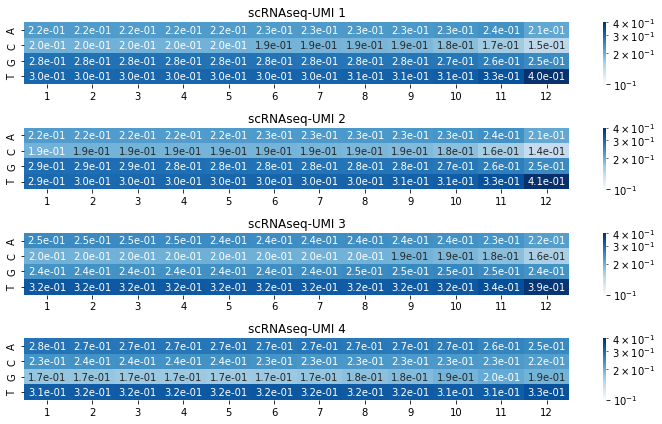

In [84]:
from matplotlib.colors import LogNorm

plt.figure(figsize=(10,6))

plt.subplot(4,1,1)
freq = pd.read_csv('frequencies/HBreastCancer.csv',index_col=0)
sns.heatmap(freq, annot=freq, fmt = '.1e',cmap='Blues', norm=LogNorm(vmin=1e-1,vmax=4e-1))
plt.xticks(np.arange(12)+0.5,np.arange(1,13))
plt.title('scRNAseq-UMI 1')

plt.subplot(4,1,2)
freq = pd.read_csv('frequencies/MBrain.csv',index_col=0)
sns.heatmap(freq, annot=freq, fmt = '.1e',cmap='Blues', norm=LogNorm(vmin=1e-1,vmax=4e-1))
plt.xticks(np.arange(12)+0.5,np.arange(1,13))
plt.title('scRNAseq-UMI 2')

plt.subplot(4,1,3)
freq = pd.read_csv('frequencies/MBrainCoronal.csv',index_col=0)
sns.heatmap(freq, annot=freq, fmt = '.1e',cmap='Blues', norm=LogNorm(vmin=1e-1,vmax=4e-1))
plt.xticks(np.arange(12)+0.5,np.arange(1,13))
plt.title('scRNAseq-UMI 3')

plt.subplot(4,1,4)
freq = pd.read_csv('frequencies/HPBMC2.csv',index_col=0)
sns.heatmap(freq, annot=freq, fmt = '.1e',cmap='Blues', norm=LogNorm(vmin=1e-1,vmax=4e-1))
plt.xticks(np.arange(12)+0.5,np.arange(1,13))
plt.title('scRNAseq-UMI 4')


plt.tight_layout()
plt.savefig('nucl_supp3.png',dpi=1200)